In [319]:
import json
import random
import csv
import re
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import pandas as pd

In [320]:
all_data = json.load(open('./raw_data.json', 'r'))
for row in all_data:
    for item in row['items']:
        del item['paramoji']['choices']
        item['paramoji']['value'] = np.round(item['paramoji']['value'],4).tolist()
    row['items']=[i for i in row['items'] if "4d5166.online-server.cloud" not in i['url']]

f = open('./raw_data_fec.json','w')
f.write(json.dumps(all_data))
f.close()

In [321]:
all_data = json.load(open('./raw_data_fec.json', 'r'))

In [322]:
len(all_data)

805

In [347]:
data = []
check_double = set()
for entry in all_data:
    unique_key = entry['workerId'] + entry['taskId']
    if unique_key in check_double:
        continue
    check_double.add(unique_key)
    data.extend(dict(item, 
                     worker=entry['workerId'],
                     paramoji_v=item['paramoji']['value'][0],
                     paramoji_a1=item['paramoji']['value'][1],
                     paramoji_a2=item['paramoji']['value'][2],
                     paramoji_p=item['paramoji']['value'][3],
                     paramoji_c=item['paramoji']['value'][4],
                    ) for item in entry['items'])
print(f"Doubles: {len(check_double)}")
print(f"Data: {len(data)}")
print(f"Workers: {len(set([r['worker'] for r in data]))}")

Doubles: 738
Data: 11916
Workers: 533


0.23841893252769386


(array([2432.,  276.,   59.,   10.,   18.,   14.,    3.,    8.,    5.,
           3.]),
 array([ 2. ,  3.7,  5.4,  7.1,  8.8, 10.5, 12.2, 13.9, 15.6, 17.3, 19. ]),
 <BarContainer object of 10 artists>)

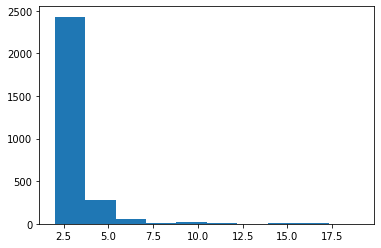

In [348]:
iters = np.array([row['paramoji']['iteration'] for row in data])
print(np.mean(iters > 1.0))
plt.hist(iters[(iters > 1.0) * (iters < 20.0)], 10)

0.455


(array([2108., 3448., 2208., 1203.,  783.,  485.,  317.,  239.,  185.,
         126.,  115.,   88.,   66.,   48.,   42.,   31.,   24.,   25.,
          20.,   21.]),
 array([ 0.455  ,  5.43105, 10.4071 , 15.38315, 20.3592 , 25.33525,
        30.3113 , 35.28735, 40.2634 , 45.23945, 50.2155 , 55.19155,
        60.1676 , 65.14365, 70.1197 , 75.09575, 80.0718 , 85.04785,
        90.0239 , 94.99995, 99.976  ]),
 <BarContainer object of 20 artists>)

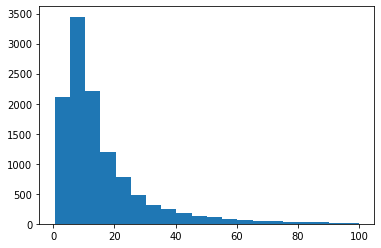

In [349]:
times= np.array([row['endTime']-row['startTime'] for row in data])/1000
print(np.min(times))
plt.hist(times[times < 100],20)

In [350]:
df = pd.DataFrame(data)
df['key']=df['url'] + '_' + [str(x) for x in df['X_min']] + '_' + [str(x) for x in df['Y_min']]
result = df.groupby('key').median().reset_index()
result['url'] = [re.sub(r'_[0-9]+_[0-9]+$','', x) for x in result['key']]
result

,key,X_min,X_max,Y_min,Y_max,Width,Height,startTime,endTime,paramoji_v,paramoji_a1,paramoji_a2,paramoji_p,paramoji_c,url
0,http://2.bp.blogspot.com/_Rij1FUW9IOU/TSwLtKCt...,42.0,263.0,3.0,258.0,300.0,300.0,1.644245e+12,1.644245e+12,0.53835,0.51675,0.06420,0.38845,0.00000,http://2.bp.blogspot.com/_Rij1FUW9IOU/TSwLtKCt...
1,http://40.media.tumblr.com/c76a8884d4692afc7f5...,91.0,478.0,53.0,504.0,584.0,575.0,1.644245e+12,1.644245e+12,0.48890,0.58400,0.13515,0.53295,0.00000,http://40.media.tumblr.com/c76a8884d4692afc7f5...
2,http://blog-imgs-71.fc2.com/m/e/r/meroute/2015...,101.0,180.0,31.0,124.0,300.0,450.0,1.644243e+12,1.644243e+12,0.34015,0.41430,0.11340,0.46160,0.00000,http://blog-imgs-71.fc2.com/m/e/r/meroute/2015...
3,http://dialoguemagazine.com/index/wp-content/u...,134.0,248.0,7.0,137.0,380.0,500.0,1.644244e+12,1.644244e+12,0.57680,0.61400,0.12400,0.31450,0.00000,http://dialoguemagazine.com/index/wp-content/u...
4,http://doartenis.ro/wp-content/uploads/2013/08...,190.0,304.0,22.0,155.0,600.0,299.0,1.644243e+12,1.644243e+12,0.36640,0.75040,0.40210,0.44090,0.72200,http://doartenis.ro/wp-content/uploads/2013/08...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
474,http://i.dailymail.co.uk/i/pix/2012/11/25/arti...,202.0,299.0,21.0,132.0,634.0,589.0,1.644243e+12,1.644243e+12,0.46350,0.16740,0.55435,0.34275,0.33785,http://i.dailymail.co.uk/i/pix/2012/11/25/arti...
475,http://i.res.24o.it/images2010/Flussi_Input/Da...,156.0,273.0,3.0,141.0,420.0,300.0,1.644245e+12,1.644245e+12,0.62635,0.71870,0.39230,0.35635,0.00000,http://i.res.24o.it/images2010/Flussi_Input/Da...
476,http://i.ytimg.com/vi/4KFQnYhAw8o/0.jpg_147_20,147.0,279.0,20.0,173.0,480.0,360.0,1.644243e+12,1.644243e+12,0.51435,0.17375,0.53095,0.74105,0.00000,http://i.ytimg.com/vi/4KFQnYhAw8o/0.jpg
477,http://s13.postimage.org/6ohs7qil3/1263059097_...,146.0,230.0,0.0,96.0,300.0,220.0,1.644244e+12,1.644244e+12,0.74715,0.47095,0.35020,0.28290,0.00000,http://s13.postimage.org/6ohs7qil3/1263059097_...


In [351]:
print(f"{len(data)}/{result.shape[0]} = {np.round(len(data)/result.shape[0])}")

11916/479 = 25.0


In [328]:
f = open('gen/fec/results.json','w')
f.write(result.to_json(orient='records'))
f.close()

# Metrics

In [329]:
data = []
for type in ["train","test"]:
    csv_file = f"../../emoticon-data/FEC_dataset/faceexp-comparison-data-{type}-public.csv"
    df = pd.read_csv(csv_file, names=[str(i) for i in range(30)], header=None)
    data.extend(df.values.tolist())
len(data)

500203

In [330]:
def has_results(row):
    translated = []
    for col in [0,5,10]:
        match_res = result[result['url']==row[col]]
        if not match_res.shape[0]:
            return None
        match_res = match_res[abs(match_res['X_min'] - row[col+1]*match_res['Width']) < 2]
        match_res = match_res[abs(match_res['Y_min'] - row[col+3]*match_res['Height']) < 2]
        match_res = match_res[abs(match_res['X_max'] - row[col+2]*match_res['Width']) < 2]
        match_res = match_res[abs(match_res['Y_max'] - row[col+4]*match_res['Height']) < 2]
        if not match_res.shape[0]:
            return None
        translated.append(match_res.index.tolist()[0])
    return translated

In [331]:
triplets = [row for row in data if has_results(row)]
len(triplets)

236

In [332]:
refs = [has_results(row) for row in triplets]
np.array(refs).shape

(236, 3)

In [333]:
paramojis=[
    np.array([result['paramoji_'+key].iloc[i] for key in ['v','a1','a2','p','c']])
    for i in range(result.shape[0])
]
np.array(paramojis).shape

(479, 5)

In [334]:
def get_label(a,b,c):
    dists = [np.linalg.norm(b-c), np.linalg.norm(a-c), np.linalg.norm(a-b)]
    return np.argmin(dists)+1
    
labels = [
    get_label(paramojis[ref[0]], paramojis[ref[1]], paramojis[ref[2]])
    for ref in refs
]

In [335]:
res2 = [
    [triplets[i][15], 
     sum(labels[i] == triplets[i][j] for j in range(17, 30, 2)),
     sum(not np.isnan(triplets[i][j]) for j in range(17, 30, 2))
    ]
    for i in range(len(triplets))
]
len(res2)

236

In [343]:
g= pd.DataFrame(res2).groupby(0)
final = g.sum().reset_index()
final['count'] = g.count().reset_index()[1]
final = final.append({
    0:'ALL',
    1:np.sum(final[1]),
    2:np.sum(final[2]),
    "count": np.sum(final['count'])}, ignore_index=True)
final['p'] = np.round(final[1]/final[2]*100+0.05,1)
final=final.drop([1,2],axis=1)
final

,0,count,p
0,ONE_CLASS_TRIPLET,94,53.3
1,THREE_CLASS_TRIPLET,55,56.1
2,TWO_CLASS_TRIPLET,87,56.2
3,ALL,236,55.0


In [344]:
final['AFFNet-Cl-P']  = [49.2,50.4,59.8,53.3]
final['FECNet-16d']   = [77.1,82.6,85.1,81.8]
final['Median rater'] = [85.3, 87.2, 89.3, 87.5]
print(final.to_latex(index=False))

\begin{tabular}{lrrrrr}
\toprule
                  0 &  count &    p &  AFFNet-Cl-P &  FECNet-16d &  Median rater \\
\midrule
  ONE\_CLASS\_TRIPLET &     94 & 53.3 &         49.2 &        77.1 &          85.3 \\
THREE\_CLASS\_TRIPLET &     55 & 56.1 &         50.4 &        82.6 &          87.2 \\
  TWO\_CLASS\_TRIPLET &     87 & 56.2 &         59.8 &        85.1 &          89.3 \\
                ALL &    236 & 55.0 &         53.3 &        81.8 &          87.5 \\
\bottomrule
\end{tabular}

